# Toimitusalueiden kartan tarkkuuden vähentäminen nopeisiin logistiikan koontinäyttöihin PROC GREDUCE -menetelmällä

## Yhteenveto

Alueellinen pakettikuljetusyhtiö tallentaa palvelualueidensa rajat tiheinä monikulmioääriviivoina, ja reitinsuunnittelun koontinäytöt piirtävät ne hitaasti. Tämä muistikirja luo synteettiset rajakoordinaatit neljälle toimitusalueelle, käyttää **PROC GREDUCE**-menetelmää merkitsemään jokainen rajapiste `DENSITY`-tasolla, ja piirtää sitten ajallaan toimitettujen osuuksien koropleettikartan **PROC GMAP**-menetelmällä pienemmällä tarkkuustasolla, jotta kartta piirtyy nopeammin ja jokainen alue pysyy silti tunnistettavana.

GREDUCE luokitteli 96 rajapistettä kolmeen tasoon: 10 pistettä tasolla `DENSITY=0`, 44 tasolla `DENSITY=2` ja 42 tasolla `DENSITY=3`. Kun säilytetään vain karkea taso (`DENSITY <= 2`), kartta pienenee 96 pisteestä 54 pisteeseen — noin 44 % vähennys — mutta kaikki neljä aluetta pysyvät selvästi tunnistettavina alla olevassa rinnakkaisvertailussa.

## Tietolähteet

Kaikki data luodaan alla olevissa DATA-vaiheissa — ei ulkoisia tiedostoja eikä verkkoyhteyttä.

| Aineisto | Rivit | Avainmuuttujat | Kuvaus |
|---------|------|---------------|-------------|
| `zonemap` | 96 (4 aluetta x 24 kärkipistettä) | `zone` (tunnus), `x`, `y` | Synteettiset suljetun monikulmion rajakoordinaatit neljälle toimitusalueelle, kukin väritetty ellipsi, joka jäljitetään 24 kärkipisteellä, jotta tiheyden vähentämisellä on jotain ohennettavaa. |
| `reducedmap` | 96 | lisää `density` | PROC GREDUCE:n tuloste: rajapisteet merkittynä `DENSITY`-tasolla (tässä 0, 2 tai 3) valikoivaa piirtämistä varten. |
| `coarsemap` | 54 | osajoukko aineistosta `reducedmap` | `DENSITY <= 2` -osajoukko — karkea, nopeasti piirtyvä taso, jota käytetään vähennetyn tarkkuuden koontinäytön kartassa. |
| `zonekpi` | 4 | `zone`, `ontime_rate`, `parcels` | Yksi vasterivi aluetta kohden: synteettinen ajallaan toimitettujen prosenttiosuus ja päivittäinen pakettimäärä, liitetty karttaan koropleettia varten. |

> **Huomio otoskoosta.** Tämä ympäristö toimii ilman lisenssiä, joten jokainen DATA-vaihe on rajattu 100 tulostettavaan havaintoon. Kartta on mitoitettu 4 alueeseen x 24 kärkipistettä = 96 pistettä, jotta koko alue mahtuu tähän rajaan; lisensoitu asennus jäljittäisi satoja kärkipisteitä aluetta kohden, jolloin GREDUCE kannattaa vielä enemmän.

# Toimitusalueiden kartan tarkkuuden vähentäminen PROC GREDUCE -menetelmällä

Logistiikkaoperaattorit visualisoivat suorituskykyä **palvelualueidensa** kartoilla — maantieteellisillä alueilla, joista varasto vastaa. Nämä aluerajat kaapataan usein mittaustarkkuudella: monta kärkipistettä monikulmiota kohden. Kun reitinsuunnittelun koontinäyttö piirtää useita alueita kerralla, kaikki tämä kärkipistetarkkuus hidastaa piirtämistä lisäämättä päätöksentekoarvoa koontinäytön mittakaavassa.

**PROC GREDUCE** ratkaisee tämän. Se tarkastelee jokaista monikulmiota ja merkitsee jokaisen rajapisteen `DENSITY`-tasolla, jossa 0 merkitsee pisteitä, jotka määrittävät olennaisen muodon, ja korkeammat tasot merkitsevät asteittain hienojakoisempaa yksityiskohtaa. Jatkossa valitaan taso lausekkeella `WHERE density <= n`, jolloin piirtyy vähennetyn tarkkuuden kartta, joka piirtyy nopeasti ja jossa jokainen alue pysyy tunnistettavana.

Tässä muistikirjassa:
1. Luodaan rajaääriviivat neljälle toimitusalueelle.
2. Ajetaan PROC GREDUCE `DENSITY`-tasojen määrittämiseksi.
3. Tarkastellaan, miten pisteet jakautuvat tiheystasoille.
4. Piirretään täystarkat ja vähennetyn tarkkuuden ajallaan-toimitus-koropleetit ja verrataan niitä.

## Vaihe 1 — Luo aluerajakartta

SAS-karttaminesto sisältää yhden havainnon jokaista **rajapistettä** kohden, jossa `ID`-muuttuja nimeää alueen ja numeeriset `x`/`y`-koordinaatit sijainnin. Jäljitämme jokaisen toimitusalueen väritettynä ellipsinä käyttäen 24 tasavälistä kulmaa, jotta monikulmiot ovat alusta alkaen riittävän tiheitä ja vähentämisellä on jotain työstettävää.

`call streaminit` kiinnittää satunnaislukusiemenen toistettavuuden vuoksi, ja `rand('uniform')` lisää pieniä epäsäännöllisyyksiä rajaan, jotta ääriviivat muistuttavat mitattuja alueita eivätkä täydellisiä ellipsejä.

In [1]:
TIEDOT zonemap;
    CALL streaminit(20260531);
    /* Neljä toimitusaluetta, kukin väritetty ellipsi 24 kärkipisteellä.
       cx/cy = alueen keskipiste, rx/ry = nimelliset säteet (alueen koko). */
    TAULUKKO cx[4] _temporary_ (12 32 20 40);
    TAULUKKO cy[4] _temporary_ (30 32 14 16);
    TAULUKKO rx[4] _temporary_ ( 8  9  6  7);
    TAULUKKO ry[4] _temporary_ ( 6  7  5  6);
    pi = constant('pi');
    nvtx = 23;                 /* 24 kärkipistettä (0..23) ääriviivaa kohden */
    TEE zone = 1 ASTI 4;
        TEE i = 0 ASTI nvtx;
            ang = 2 * pi * i / (nvtx + 1);
            /* säteittäinen satunnaisvaihtelu: +/- ~6% epäsäännöllinen reuna */
            jit = 1 + 0.12 * (rand('uniform') - 0.5);
            x = cx[zone] + rx[zone] * cos(ang) * jit;
            y = cy[zone] + ry[zone] * sin(ang) * jit;
            TULOSTE;
        LOPPU;
    LOPPU;
    SÄILYTÄ zone x y;
SUORITA;

PROSEDUURI KESKIARVOT TIEDOT=zonemap n MIN MAX nmiss;
    LUOKKA zone;
    MUUTTUJA x y;
    NIMIKE zone='Alue' x='X-koordinaatti' y='Y-koordinaatti';
SUORITA;

                                                  The MEANS Procedure

                                          Analysis Variable : x X-koordinaatti

        Alue              N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24      3.6053386     20.3284433              0
        2                    24     23.0107098     41.2087956              0
        3                    24     13.7607192     26.2351392              0
        4                    24     33.0535851     47.3028874              0
        --------------------------------------------------------------------

                                          Analysis Variable : y Y-koordinaatti

        Alue              N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24     23.9838655     35.9959368              


NOTE: DATA zonemap


NOTE: Wrote zonemap (96 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


PROC MEANS -taulukko vahvistaa synteettisen geometrian: neljä aluetta, kussakin tasan 24 rajapistettä järkevillä `x`/`y`-vaihteluväleillä eikä puuttuvia koordinaatteja. Neljä ellipsiä sijaitsevat toisiaan leikkaamattomilla alueilla (alue 1 lähellä x=12, alue 2 lähellä x=32, alueet 3 ja 4 alempana), joten koropleetti näyttää neljältä erilliseltä alueelta. Näitä ääriviivoja PROC GREDUCE tulee ohentamaan.

## Vaihe 2 — Määritä DENSITY-tasot PROC GREDUCE -menetelmällä

`ID`-lause nimeää muuttujan, joka määrittää jokaisen alueyksikön — tässä `zone`. PROC GREDUCE arvioi jokaisen alueen monikulmion erikseen (Douglas-Peucker-tyyppisellä yksinkertaistuksella) ja kirjoittaa syöttöaineiston takaisin lisäten kokonaislukumuuttujan `density`: taso 0 merkitsee harvoja pisteitä, jotka ankkuroivat olennaisen muodon, ja korkeammat tasot merkitsevät asteittain hienojakoisempaa yksityiskohtaa, jonka voi pudottaa ensin.

Annamme GREDUCE:n johtaa omat kynnysarvonsa datasta sen sijaan, että pakottaisimme kiinteät tasokoot, ja tarkastelemme sitten syntyvää jakaumaa.

                                   Säilytettyjen rajapisteiden määrä tiheystasoittain                                   

                                                   The FREQ Procedure

Tiheystaso    Frequency    Percent
-----------------------------------
0                    10     10.42
2                    44     45.83
3                    42     43.75



NOTE: PROC GREDUCE data=zonemap

NOTE: PROC GREDUCE: 96 observations with DENSITY assigned
NOTE: PROC FREQ
NOTE: ODS plot written: freq_density.spec.json
NOTE: PROC FREQ statement used.


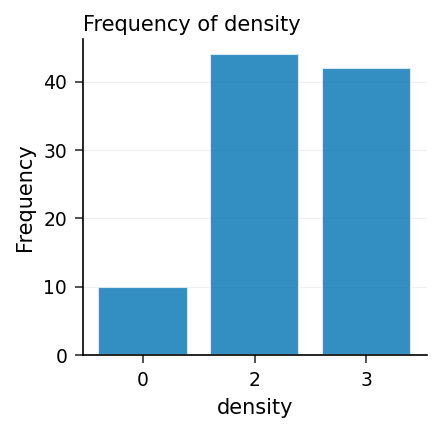

In [2]:
PROSEDUURI GREDUCE TIEDOT=zonemap out=reducedmap;
    id zone;
SUORITA;

PROSEDUURI FREKVENSSIT TIEDOT=reducedmap;
    TABLES density / nocum;
    NIMIKE density='Tiheystaso';
    OTSIKKO 'Säilytettyjen rajapisteiden määrä tiheystasoittain';
SUORITA;

## Vaihe 3 — Tarkastele tiheystasoja

Frekvenssitaulukko näyttää, miten GREDUCE luokitteli 96 rajapistettä:

| DENSITY | Pisteitä | Osuus |
|---------|--------|-------|
| 0 | 10 | 10,4 % |
| 2 | 44 | 45,8 % |
| 3 | 42 | 43,8 % |

Vain 10 pistettä kuuluu alimpaan tasoon (olennaisen muodon ankkuripisteet), kun taas loput 86 jakautuvat tasoille 2 ja 3. Koontinäytön tasoksi säilytämme kaiken tasolla `DENSITY <= 2`: se säilyttää 54 pistettä 96:sta, pudottaen 42 hienojakoisinta (`DENSITY=3`) kärkipistettä. Alla oleva PROC MEANS vahvistaa, että karkea taso sisältää 13–14 kärkipistettä aluetta kohden alkuperäisen 24:n sijaan.

In [3]:
PROSEDUURI KESKIARVOT TIEDOT=reducedmap n;
    LUOKKA zone;
    MISSÄ density <= 2;
    MUUTTUJA x;
    NIMIKE zone='Alue' x='X-koordinaatti';
    OTSIKKO 'Kärkipisteet aluetta kohden koontinäytön tarkkuudella (density <= 2)';
SUORITA;

                          Kärkipisteet aluetta kohden koontinäytön tarkkuudella (density <= 2)                          

                                                  The MEANS Procedure

                                          Analysis Variable : X X-koordinaatti

        Alue              N Obs
        -----------------------
        1                    14
        2                    13
        3                    14
        4                    13
        -----------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Vaihe 4 — Rakenna karkea kartta ja aluekohtainen suoritusvaste

Materialisoimme koontinäytön tason nimellä `coarsemap` (`DENSITY <= 2`), jotta PROC GMAP voi piirtää vähennetyn ääriviivan suoraan. Luomme myös yhden KPI-rivin aluetta kohden — **ajallaan toimitettujen osuuden** ja **päivittäisen pakettimäärän** — avaimena `zone`, jotta GMAP voi värittää jokaisen alueen.

In [4]:
TIEDOT coarsemap;
    ASETA reducedmap;
    MISSÄ density <= 2;
SUORITA;

TIEDOT zonekpi;
    CALL streaminit(771);
    TEE zone = 1 ASTI 4;
        /* ajallaan toimitettu osuus keskimäärin noin 92 %, realistinen hajonta */
        ontime_rate = round(88 + 8 * rand('beta', 5, 2), 0.1);
        parcels     = round(2000 + 6000 * rand('uniform'));
        TULOSTE;
    LOPPU;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=zonekpi noobs;
    NIMIKE zone='Alue' ontime_rate='Ajallaan toimitettu (%)' parcels='Pakettien määrä';
    OTSIKKO 'Synteettiset toimitus-KPI:t alueittain';
SUORITA;

                                         Synteettiset toimitus-KPI:t alueittain                                         

Alue  Ajallaan toimitettu (%)     Pakettien määrä
   1                     92.6                4704
   2                     95.6                2932
   3                     93.4                2934
   4                     94.6                2516




NOTE: DATA coarsemap


NOTE: Read 96 rows from reducedmap.
NOTE: Wrote coarsemap (54 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA zonekpi


NOTE: Wrote zonekpi (4 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=zonekpi

NOTE: PROC PRINT completed: 4 observations printed, 3 variables


Neljä synteettistä ajallaan-toimitusosuutta asettuvat välille 92,6 % – 95,6 %, päivittäisten pakettimäärien vaihdellessa noin 2 500:sta 4 700:aan. Alue 2 on vahvin suoriutuja 95,6 %:lla; alue 1 on heikoin 92,6 %:lla. Nämä ovat arvot, jotka koropleetin väriluokat koodaavat.

## Vaihe 5 — Piirrä täystarkat ja vähennetyn tarkkuuden koropleetit

Piirrämme saman ajallaan-toimitus-koropleetin kahdesti: kerran täydestä 96-kärkipisteisestä `reducedmap`-aineistosta ja kerran 54-kärkipisteisestä `coarsemap`-aineistosta. `MAP=` toimittaa rajat, `DATA=` KPI-vasteen, ja molemmat jakavat `zone`-tunnuksen. `CHORO`-lause täyttää jokaisen alueen `ontime_rate`-arvon mukaan käyttäen `LEVELS=4` väriluokkaa ja `COUTLINE=` teräviä rajoja varten. Kahden kartan vertailu näyttää, mitä vähentäminen maksaa visuaalisesti.

                                            Täysi tarkkuus: 96 rajapistettä                                             




NOTE: Option TITLE changed to Täysi tarkkuus: 96 rajapistettä.
NOTE: PROC GMAP map=reducedmap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable ontime_rate.
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.43 seconds
  cpu   0.43 seconds


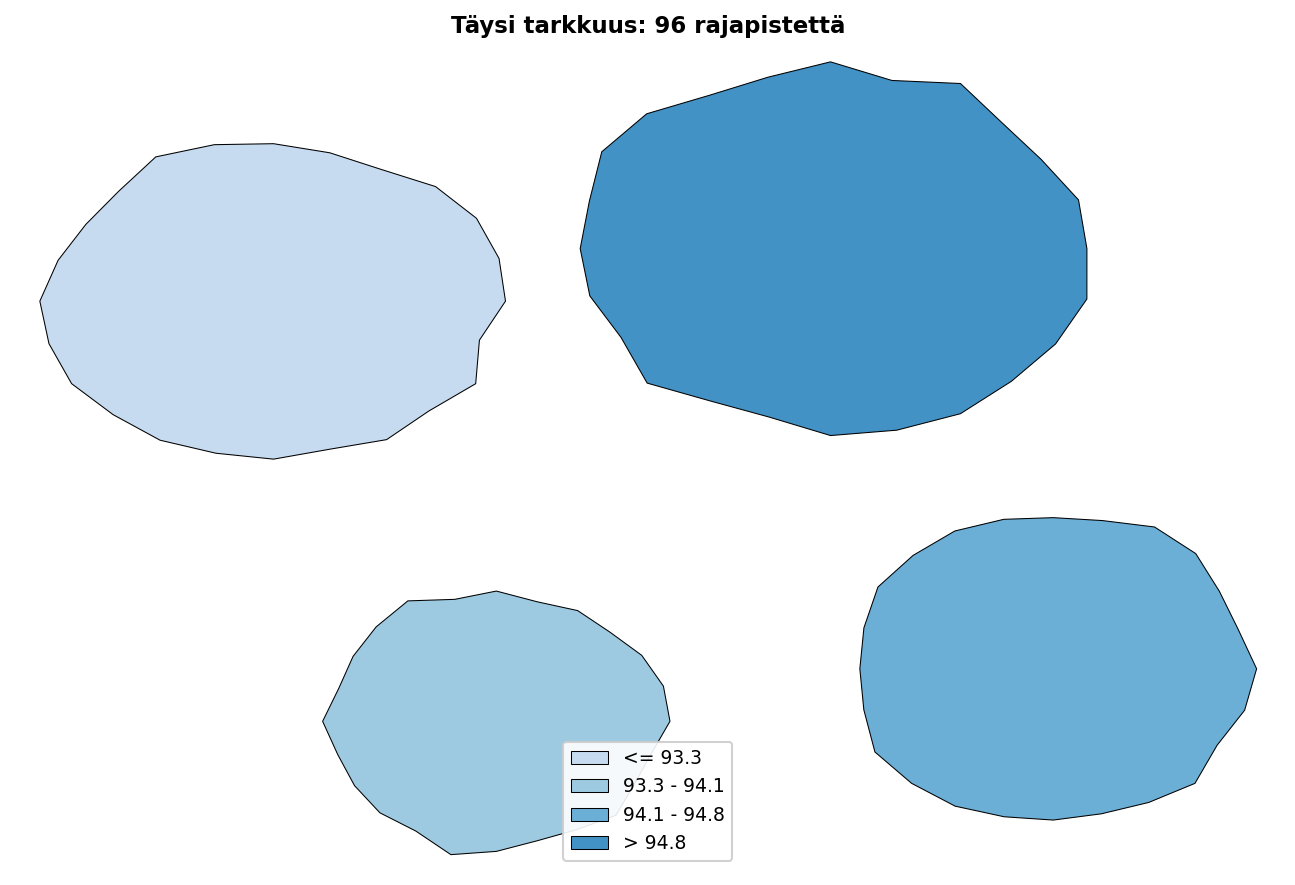

In [5]:
OTSIKKO 'Täysi tarkkuus: 96 rajapistettä';
PROSEDUURI GMAP map=reducedmap TIEDOT=zonekpi;
    id zone;
    CHORO ontime_rate / levels=4 coutline=black;
SUORITA;

                                    Vähennetty tarkkuus: 54 pistettä (density <= 2)                                     




NOTE: Option TITLE changed to Vähennetty tarkkuus: 54 pistettä (density <= 2).
NOTE: PROC GMAP map=coarsemap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable ontime_rate.
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.42 seconds
  cpu   0.42 seconds


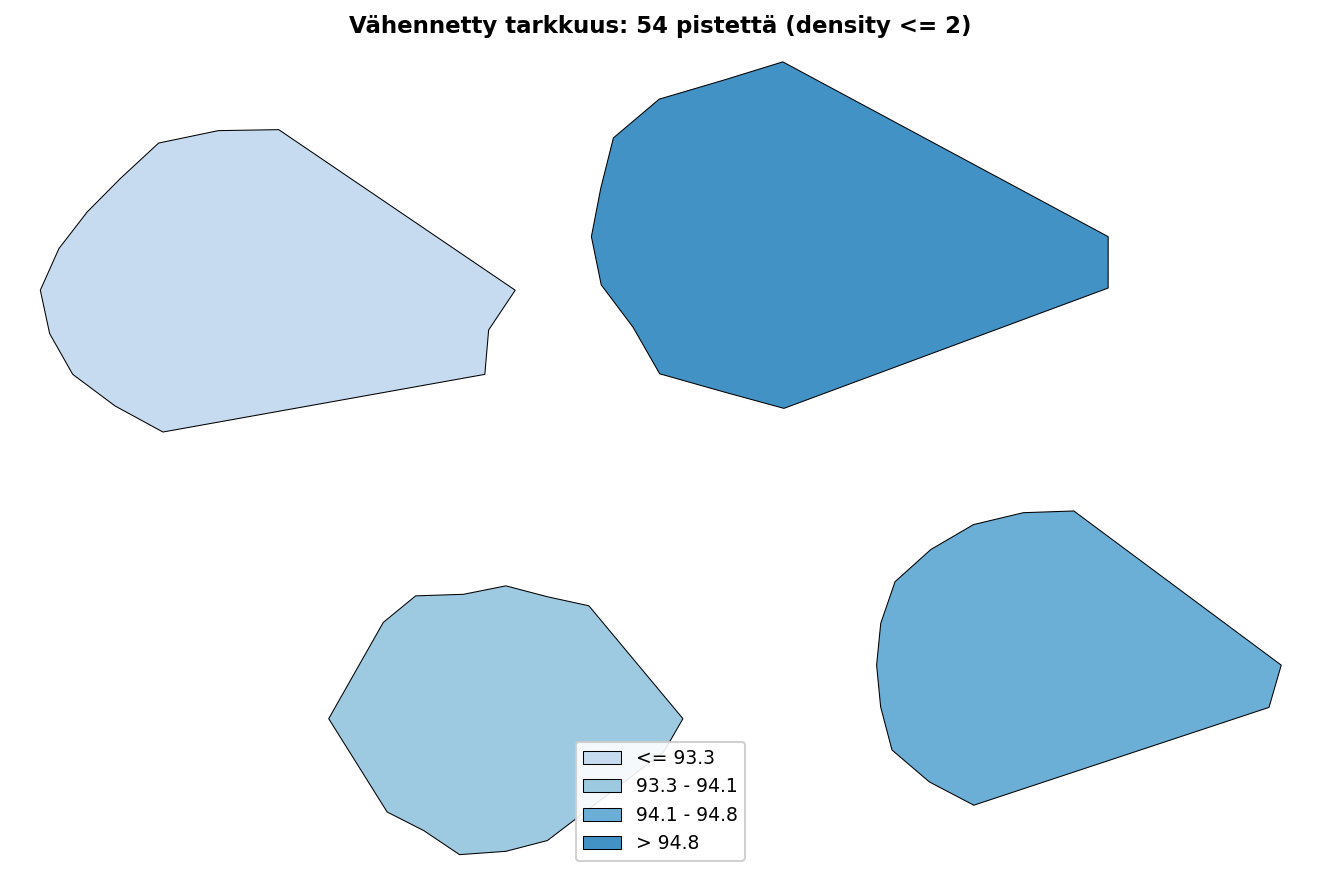

In [6]:
OTSIKKO 'Vähennetty tarkkuus: 54 pistettä (density <= 2)';
PROSEDUURI GMAP map=coarsemap TIEDOT=zonekpi;
    id zone;
    CHORO ontime_rate / levels=4 coutline=black;
SUORITA;

## Tulosten tulkinta

PROC GREDUCE muunsi jokaisen 24-kärkipisteisen aluerajan asteikolliseksi joukoksi rajapisteitä (tasot 0, 2 ja 3 tässä ajossa). `DENSITY <= 2` -tason valinta pienensi kartan 96 kärkipisteestä 54:ään — 44 %:n vähennys pisteissä, jotka piirtimen on piirrettävä — mutta rinnakkaiset koropleetit vahvistavat, että neljä aluetta pysyvät selvästi tunnistettavina: vähennetyn kartan ääriviivat ovat näkyvästi kulmikkaammat, mutta jokainen alue säilyttää sijaintinsa, kokonsa ja väriluokkansa, joten operaattori lukee saman tuloskortin kummallakin tavalla.

Tämä tuloskortti järjestää alueet ajallaan toimittamisen mukaan: alue 2 johtaa 95,6 %:lla (tummin luokka), alueet 3 ja 4 sijoittuvat keskikastiin noin 93–95 %:iin, ja alue 1 jää viimeiseksi 92,6 %:lla (vaalein luokka) — alue, jota suunnittelija tutkisi ensimmäisenä reititys- tai varastokapasiteettiongelmien varalta.

Koska vähentäminen ei ole tuhoavaa — täystarkat pisteet elävät edelleen aineistossa `reducedmap` — sama aineisto tukee sekä nopeaa koontinäyttönäkymää (`DENSITY <= 2`) että korkearesoluutioista tulostus- tai auditointinäkymää (`DENSITY <= 3`, tai koko joukko) vaihtamalla yhtä `WHERE`-kynnysarvoa, ilman tarvetta tuoda tai vähentää geometriaa uudelleen.